# Load Project Data

In [3]:
import numpy as np
import pandas as pd
# import gdown
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import math
# from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

In [4]:
# ==============================
# Load Project Data
# ==============================

# gid_path = "1qvELtIxFwFRJ3lLPI0PvLrhH_6VPwxXY"

# gdown.download(
#     id = gid_path,
#     output="get_it_done_requests_closed_2025_datasd.csv",
#     quiet=False
# )

gid_requests = pd.read_csv("get_it_done_requests_closed_2025_datasd.csv")

# High-Level Overview and MetaData Report

In [5]:
gid_requests.shape

(378669, 23)

In [6]:
gid_requests.head()

,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,date_closed,status,...,zipcode,council_district,comm_plan_code,comm_plan_name,park_name,case_origin,referred,iamfloc,floc,public_description
0,5152704,NaN,NaN,2025-03-19 16:20:00.000,0,TSW,Pothole,NaN,2025-03-19,Referred,...,NaN,6.0,15.0,MIRA MESA,NaN,Mobile,This report has been referred to appropriate d...,SS-001649-PV1,SS-001649-PV1,Broken cover. || LOCATION: 7489 Acama st 92126...
1,5152705,NaN,NaN,2025-03-19 16:22:00.000,1,ESD Complaint/Report,Missed Collection,Missed Collection,2025-03-20,Closed,...,92109.0,2.0,18.0,MISSION BEACH,NaN,Web,NaN,SS-035651-PV1,SA-002923-PV1,Third attempt has not been picked up
2,5152711,NaN,NaN,2025-03-19 16:25:00.000,27,Parking,Parking Violation,72 Hour Violation,2025-04-15,Closed,...,92117.0,2.0,6.0,CLAIREMONT MESA,NaN,Web,NaN,SS-013181,SS-013181,Van has been parked for over a month. Windows ...
3,5152712,NaN,NaN,2025-03-19 16:25:00.000,14,Neighborhood Policing,Encampment,NaN,2025-04-02,Closed,...,92101.0,2.0,14.0,MIDWAY-PACIFIC HIGHWAY,NaN,Web,NaN,SS-030076-PV1,SS-030076-PV1,A homeless encampment fire was reported at W. ...
4,5152714,NaN,NaN,2025-03-19 16:29:00.000,3,Parking,Parking Violation,72 Hour Violation,2025-03-22,Closed,...,92110.0,2.0,6.0,CLAIREMONT MESA,NaN,Web,NaN,SS-018336,SS-018336,Van has been parked on the curb since March 11...


In [7]:
gid_requests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378669 entries, 0 to 378668
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   service_request_id         378669 non-null  int64  
 1   service_request_parent_id  41999 non-null   float64
 2   sap_notification_number    46831 non-null   float64
 3   date_requested             378669 non-null  object 
 4   case_age_days              378669 non-null  int64  
 5   case_record_type           378669 non-null  object 
 6   service_name               378489 non-null  object 
 7   service_name_detail        240280 non-null  object 
 8   date_closed                378669 non-null  object 
 9   status                     378669 non-null  object 
 10  lat                        378270 non-null  float64
 11  lng                        378270 non-null  float64
 12  street_address             377569 non-null  object 
 13  zipcode                    37

In [8]:
gid_requests["zipcode"] = (
    gid_requests["zipcode"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

gid_requests["comm_plan_code"] = (
    gid_requests["comm_plan_code"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

gid_requests["council_district"] = (
    gid_requests["council_district"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

In [9]:
gid_requests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378669 entries, 0 to 378668
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   service_request_id         378669 non-null  int64  
 1   service_request_parent_id  41999 non-null   float64
 2   sap_notification_number    46831 non-null   float64
 3   date_requested             378669 non-null  object 
 4   case_age_days              378669 non-null  int64  
 5   case_record_type           378669 non-null  object 
 6   service_name               378489 non-null  object 
 7   service_name_detail        240280 non-null  object 
 8   date_closed                378669 non-null  object 
 9   status                     378669 non-null  object 
 10  lat                        378270 non-null  float64
 11  lng                        378270 non-null  float64
 12  street_address             377569 non-null  object 
 13  zipcode                    37

Observed that there are no integer-coded categorical features that need to be switched to categorical types

In [10]:
gid_requests.nunique()

service_request_id           378669
service_request_parent_id     25696
sap_notification_number       46830
date_requested               234665
case_age_days                  2442
case_record_type                 12
service_name                     42
service_name_detail             262
date_closed                     365
status                            2
lat                          321560
lng                          319863
street_address               187351
zipcode                          67
council_district                 10
comm_plan_code                   58
comm_plan_name                   59
park_name                       368
case_origin                      21
referred                      14536
iamfloc                       69634
floc                          52199
public_description           243567
dtype: int64

In [11]:
def create_metadata(df) :
    # Initialize DataFrame object with index (row names) as feature names
    meta = pd.DataFrame(index=df.columns)
    # Extract variable types
    meta['dtype'] = df.dtypes
    # Extract number of unique values
    meta['n_unique'] = df.nunique()
    # Number of missing values
    meta['missing_sum'] = df.isnull().sum()
    # Whether feature is numeric
    meta['is_numeric'] = meta['dtype'].apply(
        lambda x: pd.api.types.is_numeric_dtype(x)
    )
    # Whether feature is categorical
    meta['is_categorical'] = meta['dtype'].apply(
        lambda x: isinstance(x, pd.CategoricalDtype) or x == object
    )
    # Sample of values (that are not missing) from dataset
    #meta['sample_values'] = df.apply(lambda col: col.dropna().unique()[:5])
    # Return metadata DataFrame
    return meta

# Run the method on DataFrame and generate report
meta_df = create_metadata(gid_requests)

# Export to CSV file
meta_df.to_csv("metadata_report.csv")

meta_df.head(25)

,dtype,n_unique,missing_sum,is_numeric,is_categorical
service_request_id,int64,378669,0,True,False
service_request_parent_id,float64,25696,336670,True,False
sap_notification_number,float64,46830,331838,True,False
date_requested,object,234665,0,False,True
case_age_days,int64,2442,0,True,False
case_record_type,object,12,0,False,True
service_name,object,42,180,False,True
service_name_detail,object,262,138389,False,True
date_closed,object,365,0,False,True
status,object,2,0,False,True


# Exploratory Data Analysis

In [12]:
# Count, Mean, Standard Deviation, Min,
# Q1, Median, Q3, Max
summary = gid_requests.describe(include = "int64").T

# Skewness describes whether data is assymetric (not centered)
summary["skew"] = gid_requests.select_dtypes(
    include = "int64"
).skew()

# Kurtosis describes whether data is heavy-tailed (outliers)
summary["kurtosis"] = gid_requests.select_dtypes(
    include = "int64"
).kurt()

summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
service_request_id,378669.0,5.221576e+06,297641.883433,82529.0,5138245.0,5253320.0,5373489.0,5606526.0,-6.794564,79.371714
case_age_days,378669.0,4.609077e+01,194.383769,-124.0,0.0,2.0,14.0,3478.0,8.064617,81.012409


Observe that case_age_days is probably the only numeric column here with any real meaning

In [13]:
def plot_boxplot_grid(
    df, cols_per_row=5, figsize_per_plot=(4, 3),
    title='Boxplots of Numeric Features'
):
    # Extract numeric features & calculate plots per row in grid
    numeric_cols = df.select_dtypes(include='int64').columns
    n_cols = len(numeric_cols)

    # Determine grid size
    n_rows = math.ceil(n_cols / cols_per_row)

    # Setup subplots
    fig, axes = plt.subplots(
        n_rows, cols_per_row,
        figsize=(cols_per_row * figsize_per_plot[0],
                 n_rows * figsize_per_plot[1])
    )
    axes = axes.flatten()

    # Create each boxplot
    for i, col in enumerate(numeric_cols):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_xlabel("")

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.show()

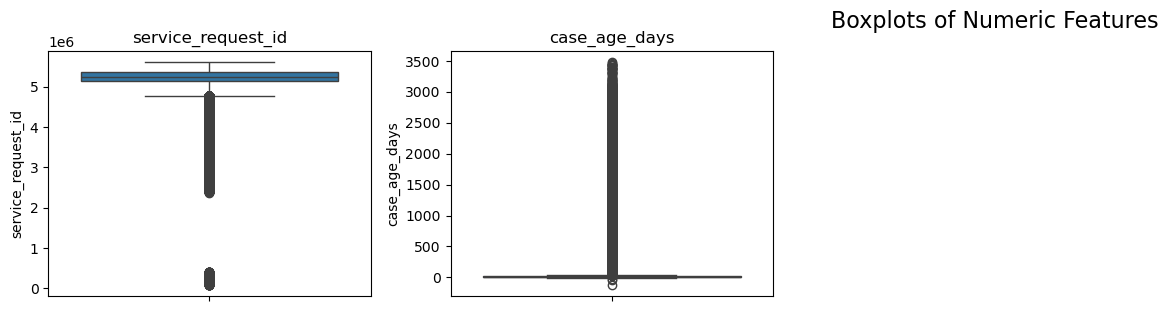

In [14]:
plot_boxplot_grid(df = gid_requests)

Some outliers are squishing the box plot for case age days (don't really care about service request ID)

In [15]:
gid_requests["case_age_days"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

0.50       2.00
0.75      14.00
0.90      67.00
0.95     182.00
0.99     958.32
1.00    3478.00
Name: case_age_days, dtype: float64

Boxplot for case age days with outliers removed

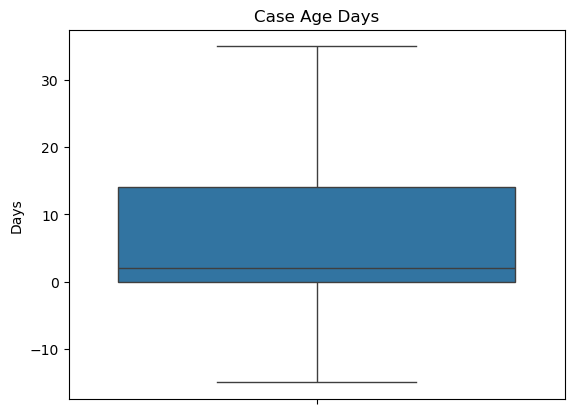

In [16]:
sns.boxplot(
    y=gid_requests["case_age_days"],
    showfliers=False
)

plt.title("Case Age Days")
plt.ylabel("Days")
plt.show()

In [17]:
# explore case age days < 0 (these should probably be REMOVED)
gid_requests[gid_requests['case_age_days'] < 0]

,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,date_closed,status,...,zipcode,council_district,comm_plan_code,comm_plan_name,park_name,case_origin,referred,iamfloc,floc,public_description
378502,5443648,5404526.0,NaN,2025-11-08 09:10:00.000,-22,Parks & Recreation,Tree Maintenance,EVALUATE TREE FOR REMOVAL,2025-10-17,Closed,...,92103,3,42,UPTOWN,MISSION HILLS NP,Mobile,NaN,TR-RW-0180477,SS-022393,Dead 40 foot pine tree in South-West corner of...
378579,5508054,5419383.0,4.030107e+10,2025-12-29 17:16:00.000,-41,TSW ROW,Vegetation Encroachment,NaN,2025-11-18,Closed,...,92173,8,33,SAN YSIDRO,NaN,Web,NaN,SS-004183-SE1,SS-004183,There are two very large trees that have tree ...
378582,5478324,5184714.0,NaN,2025-12-05 10:17:00.000,-15,TSW,Traffic Sign Maintenance,NaN,2025-11-20,Closed,...,92128,5,3,CARMEL MOUNTAIN RANCH,NaN,Mobile,NaN,SS-022700,SS-022700,Faded Bike Lane/No Parking sign on Rancho Carm...
378642,5606526,5426964.0,NaN,2026-03-01 11:14:00.000,-124,Parks & Recreation,Parks Issue,Potential Tree Hazard,2025-10-28,Closed,...,92119,7,20,NAVAJO,NaN,Mobile,NaN,TR-RW-0025279,SS-019519,Pepper trees on City property are SIGNIFICANTL...


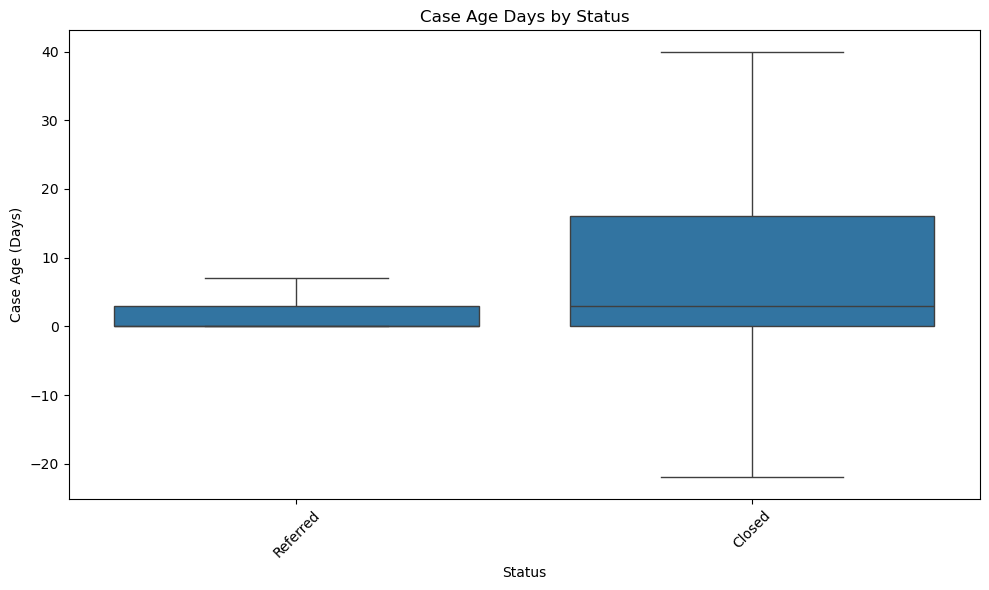

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=gid_requests,
    x="status",
    y="case_age_days",
    showfliers=False
)

plt.title("Case Age Days by Status")
plt.xlabel("Status")
plt.ylabel("Case Age (Days)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
(gid_requests["status"] == "Referred").sum()

27958

Going to remove cases referred

Inspecting outliers in code below (15 standard deviations from mean for case age days) - going to leave them in for now

In [20]:
# Filter to Closed cases
closed_cases = gid_requests[gid_requests["status"] == "Closed"].copy()

# Calculate mean and standard deviation
mean_age = closed_cases["case_age_days"].mean()
std_age = closed_cases["case_age_days"].std()

# Define +/- 3 standard deviations
lower_bound = mean_age - (15 * std_age)
upper_bound = mean_age + (15 * std_age)

# Find cases outside those bounds
closed_outliers = closed_cases[
    (closed_cases["case_age_days"] < lower_bound) |
    (closed_cases["case_age_days"] > upper_bound)
]


print(closed_outliers.shape)
closed_outliers.head()

(57, 23)


,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,date_closed,status,...,zipcode,council_district,comm_plan_code,comm_plan_name,park_name,case_origin,referred,iamfloc,floc,public_description
75683,86874,NaN,4.030000e+10,2016-06-08 18:45:00.000,3478,TSW,Pavement Maintenance,DAMAGED CURB,2025-12-16,Closed,...,nan,9,58,MID-CITY:KENSINGTON-TALMADGE,NaN,Mobile,NaN,SS-015118-PV1,SS-015118,Curb and sidewalk came in damaged for over thr...
75684,91703,NaN,4.030000e+10,2016-07-05 21:26:00.000,3465,TSW,Pavement Maintenance,DAMAGED CURB,2025-12-30,Closed,...,nan,9,59,MID-CITY:NORMAL HEIGHTS,NaN,Mobile,NaN,SS-000937-PV1,SS-000937,It was broken when a city crew replaced the fi...
75685,93180,NaN,4.030000e+10,2016-07-13 15:56:00.000,3313,TSW,Pavement Maintenance,DAMAGED CURB,2025-08-08,Closed,...,nan,3,42,UPTOWN,NaN,Mobile,NaN,SS-029821-PV1,SS-029821,"Curb needs replacement, trip hazard, north cur..."
75686,95710,NaN,4.030000e+10,2016-07-25 20:30:00.000,3431,TSW,Pavement Maintenance,DAMAGED CURB,2025-12-16,Closed,...,nan,9,58,MID-CITY:KENSINGTON-TALMADGE,NaN,Web,NaN,SS-017647-PV1,SS-017647,The curb in front of our home is deteriorating...
75907,94155,NaN,4.030001e+10,2016-07-18 16:02:00.000,3411,TSW,Stormwater,DRAIN OUTFALL,2025-11-19,Closed,...,nan,3,42,UPTOWN,NaN,Web,NaN,OT00225,SS-012872,We have no drain from North Guy Street (upper)...


Removal of referred requests

In [21]:
closed_requests = gid_requests[
    gid_requests["status"] == "Closed"
].copy()

closed_requests["council_district"] = closed_requests["council_district"].astype("category")
print(closed_requests.shape)
closed_requests = closed_requests[closed_requests["case_age_days"] >= 0]
print(closed_requests.shape)

(350711, 23)
(350707, 23)


In [22]:
# Count, Mean, Standard Deviation, Min,
# Q1, Median, Q3, Max
summary = closed_requests.describe(include = "int64").T

# Skewness describes whether data is assymetric (not centered)
summary["skew"] = closed_requests.select_dtypes(
    include = "int64"
).skew()

# Kurtosis describes whether data is heavy-tailed (outliers)
summary["kurtosis"] = closed_requests.select_dtypes(
    include = "int64"
).kurt()

summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
service_request_id,350707.0,5.218708e+06,306173.267208,82529.0,5137512.5,5253419.0,5373325.0,5510689.0,-6.685934,75.752407
case_age_days,350707.0,4.912020e+01,201.128714,0.0,0.0,3.0,16.0,3478.0,7.793117,75.473847


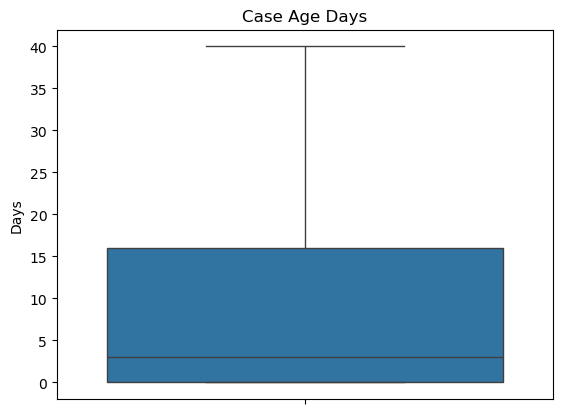

In [23]:
# revised boxplot to use in paper
sns.boxplot(
    y=closed_requests["case_age_days"],
    showfliers=False
)

plt.title("Case Age Days")
plt.ylabel("Days")
plt.savefig("box_plot_case_age_days.png")
plt.show()


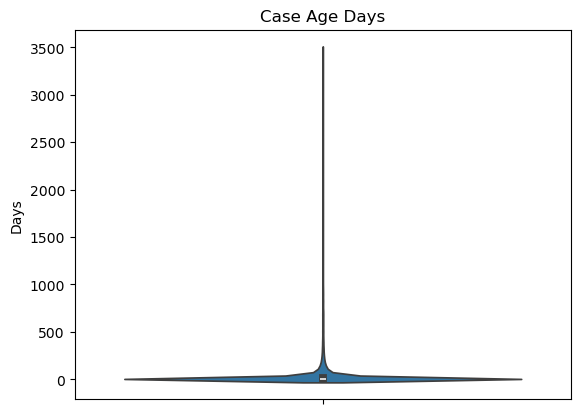

In [24]:
sns.violinplot(
    y=closed_requests["case_age_days"]
)

plt.title("Case Age Days")
plt.ylabel("Days")
plt.show()

Lots of skew, going to keep outliers for now but might consider removing them later on

Box plots by categorical features (case record type and council district)

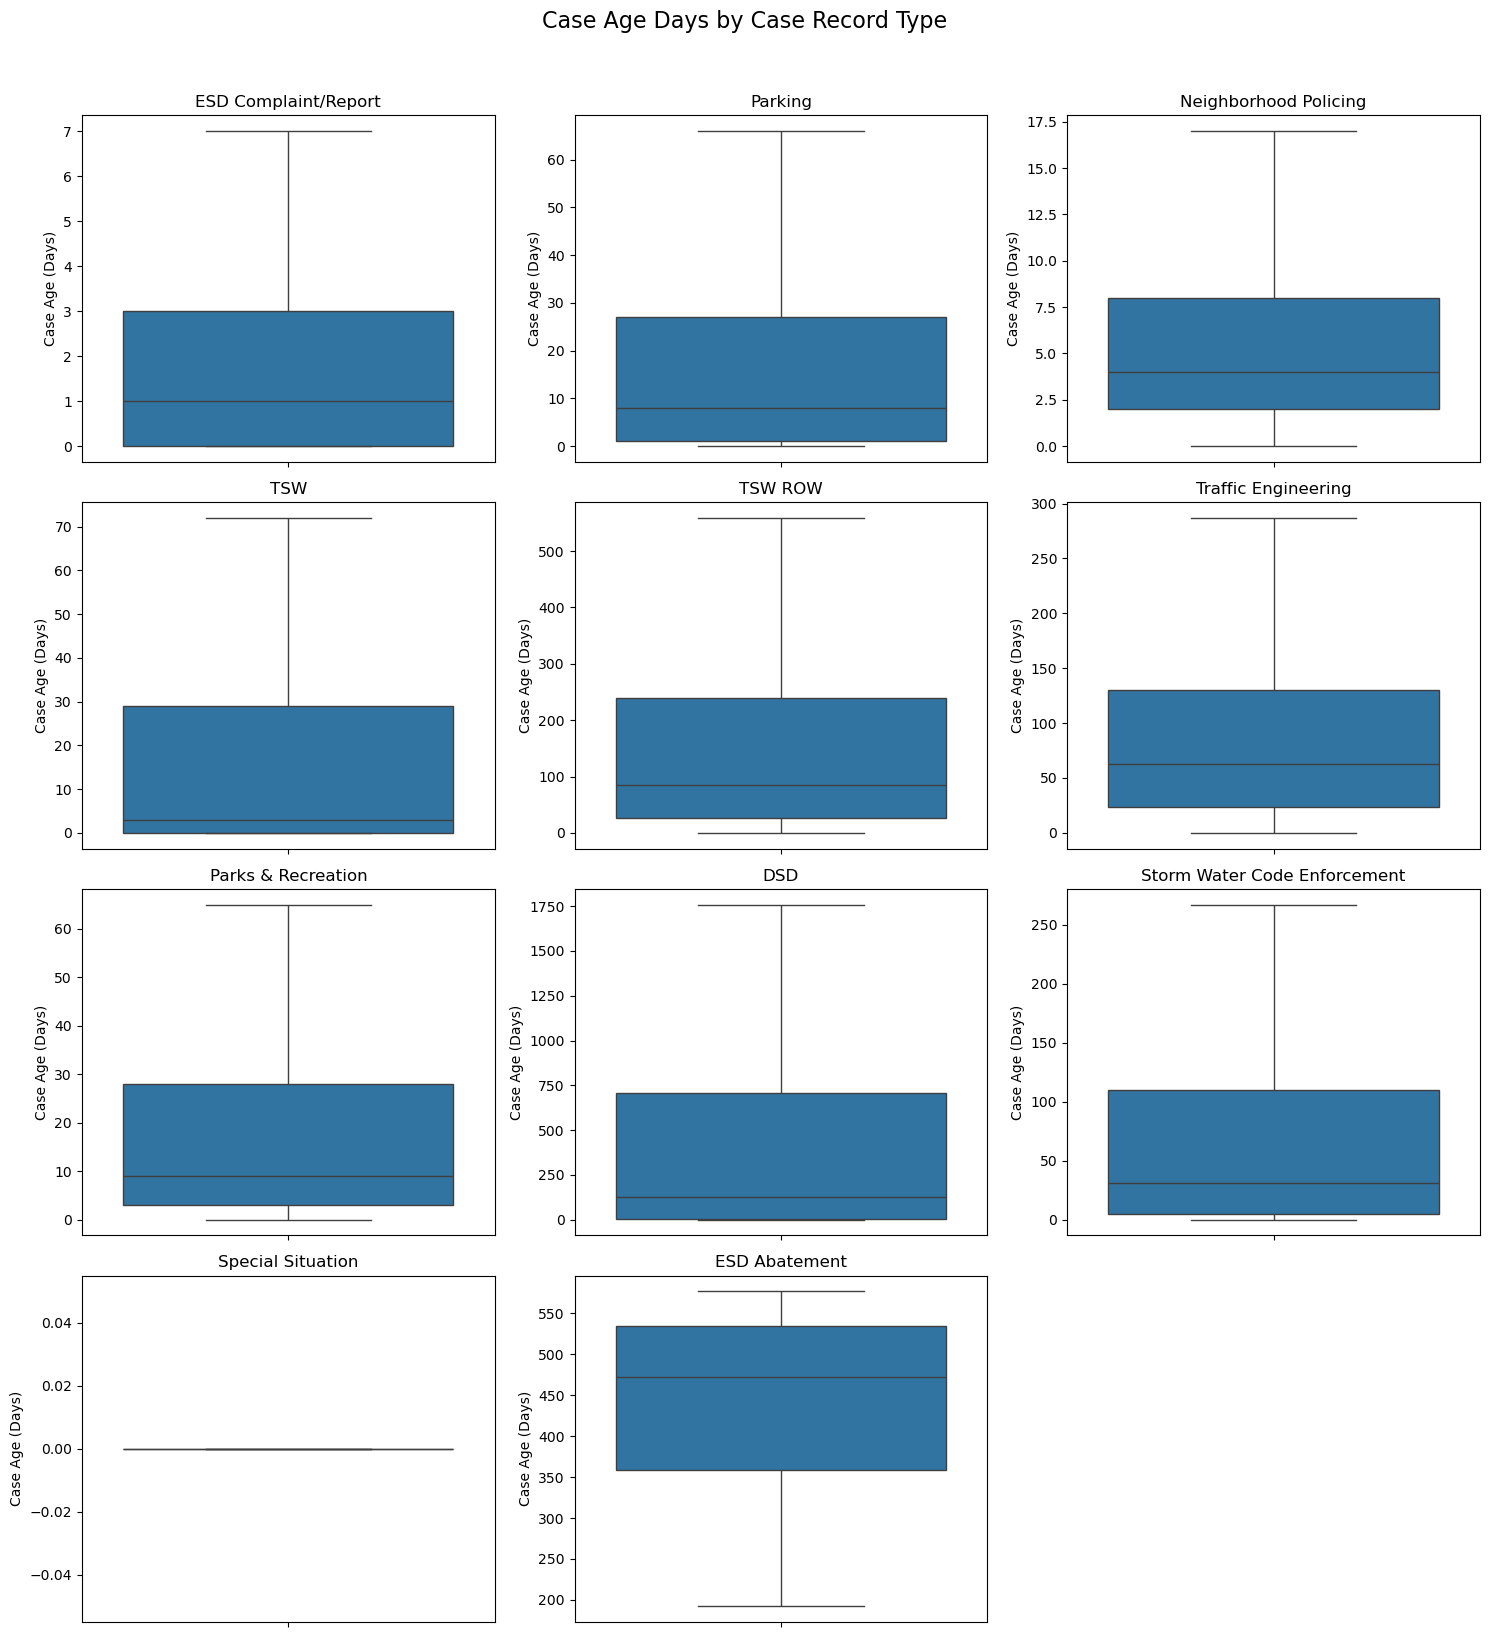

In [25]:
# Get all unique case record types
record_types = closed_requests["case_record_type"].dropna().unique()

# Number of plots per row
cols_per_row = 3

# Calculate number of rows needed
n_rows = math.ceil(len(record_types) / cols_per_row)

# Create grid
fig, axes = plt.subplots(
    n_rows,
    cols_per_row,
    figsize=(15, 4 * n_rows)
)

# Flatten axes so they're easier to loop through
axes = axes.flatten()

# Create one boxplot for each case record type
for i, record_type in enumerate(record_types):

    subset = closed_requests[
        closed_requests["case_record_type"] == record_type
    ]

    sns.boxplot(
        y=subset["case_age_days"],
        ax=axes[i],
        showfliers=False
    )

    axes[i].set_title(record_type)
    axes[i].set_ylabel("Case Age (Days)")
    axes[i].set_xlabel("")

# Remove unused plots
for j in range(len(record_types), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Case Age Days by Case Record Type",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.savefig("box_plot_case_type.png")
plt.show()

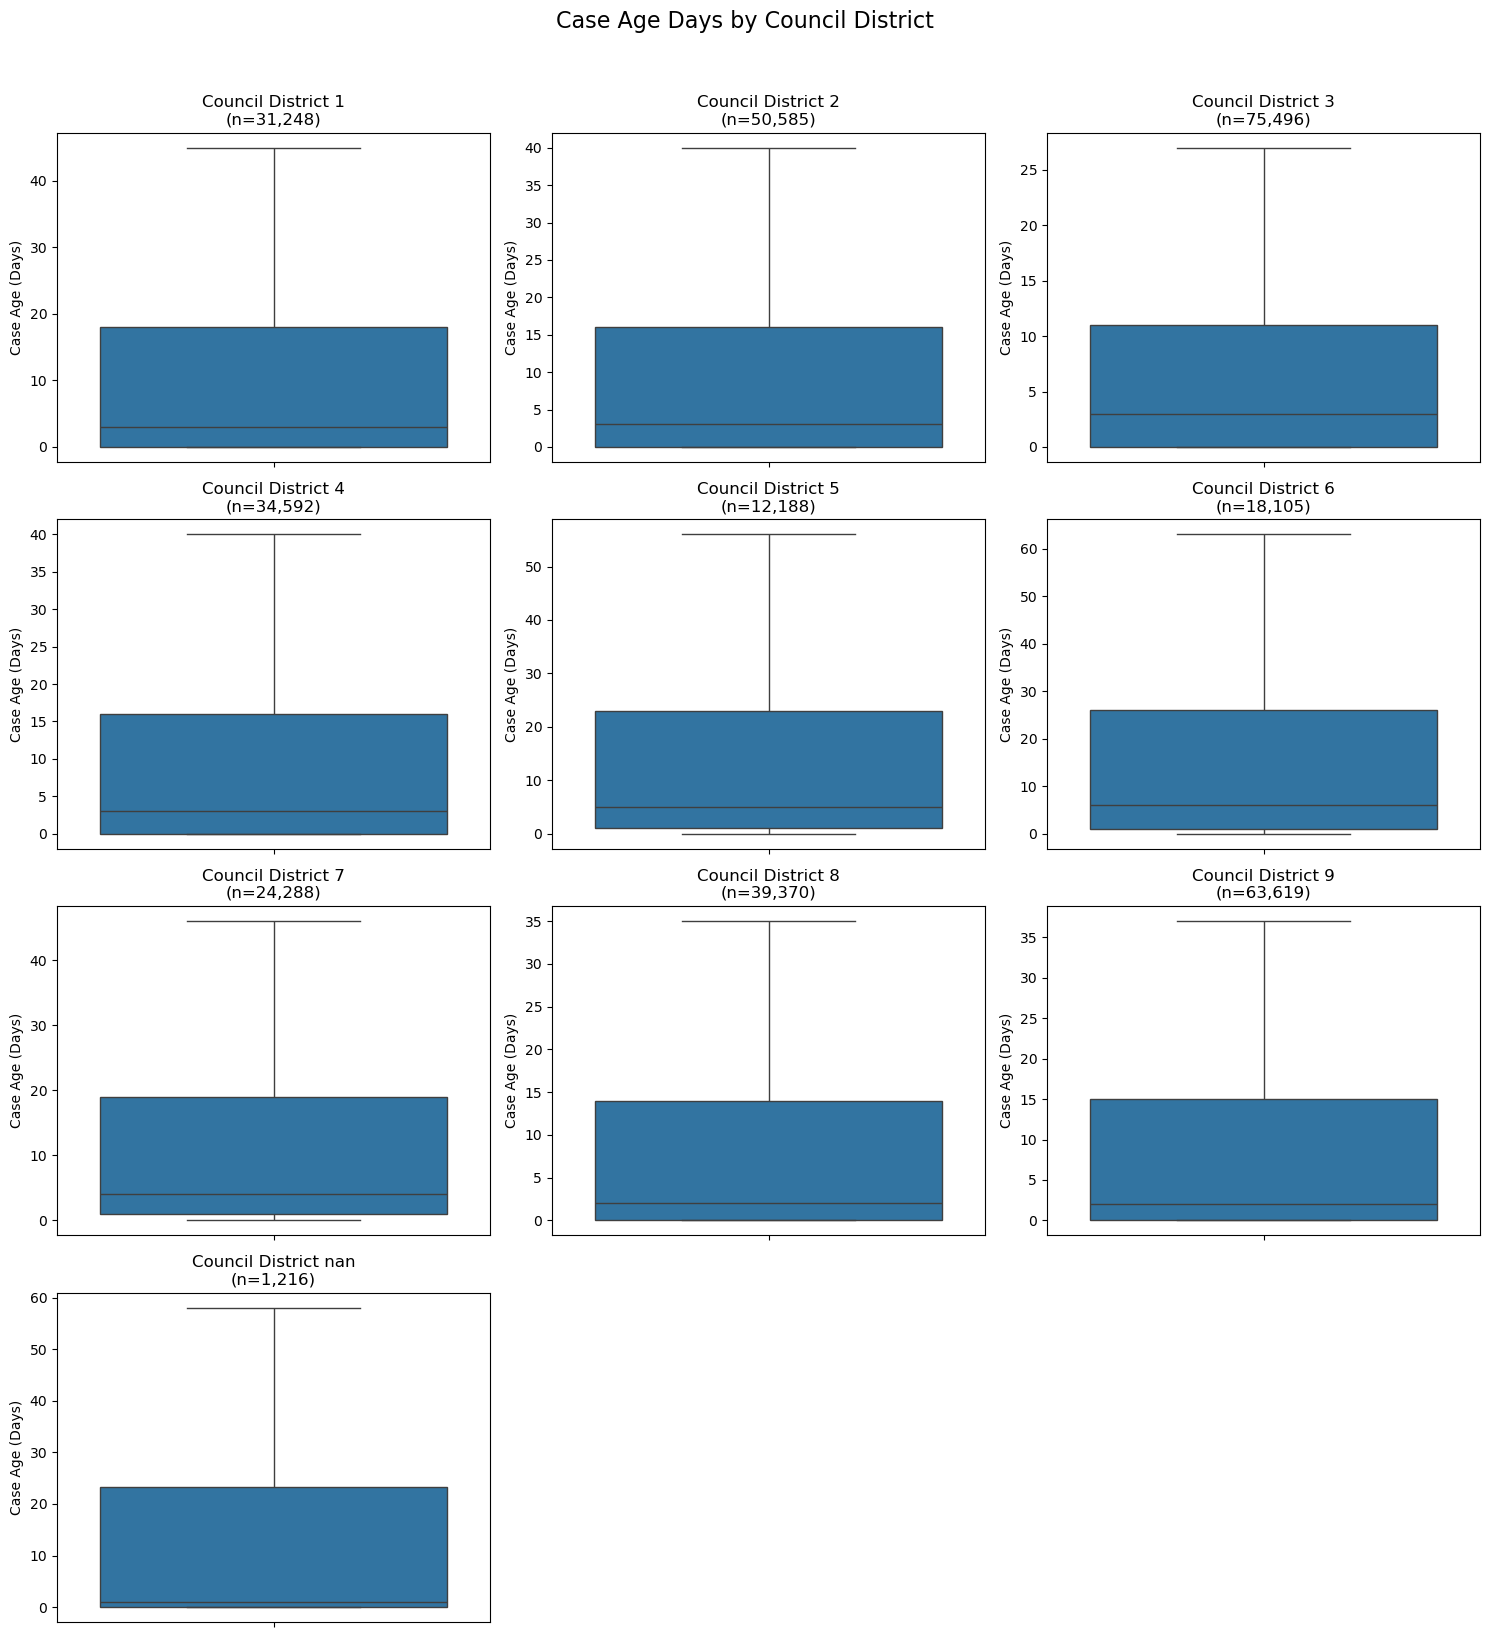

In [26]:
# Get all unique council districts
districts = sorted(
    closed_requests["council_district"].dropna().unique()
)

# Number of plots per row
cols_per_row = 3

# Calculate number of rows
n_rows = math.ceil(len(districts) / cols_per_row)

# Create grid
fig, axes = plt.subplots(
    n_rows,
    cols_per_row,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

# Create one boxplot per council district
for i, district in enumerate(districts):

    subset = closed_requests[
        closed_requests["council_district"] == district
    ]

    sns.boxplot(
        y=subset["case_age_days"],
        ax=axes[i],
        showfliers=False
    )

    axes[i].set_title(
        f"Council District {district}\n(n={len(subset):,})"
    )
    axes[i].set_ylabel("Case Age (Days)")
    axes[i].set_xlabel("")

# Remove unused plots
for j in range(len(districts), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Case Age Days by Council District",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

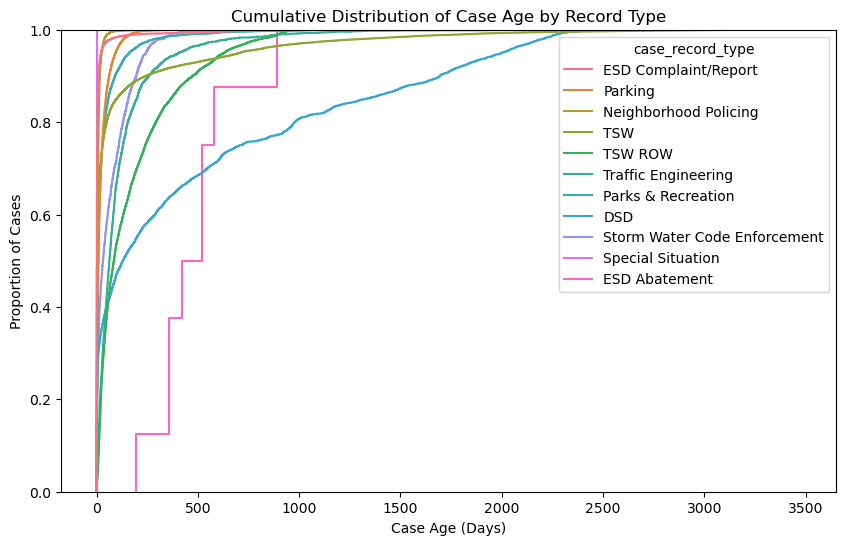

In [27]:
plt.figure(figsize=(10, 6))

sns.ecdfplot(
    data=closed_requests,
    x="case_age_days",
    hue="case_record_type"
)

plt.xlabel("Case Age (Days)")
plt.ylabel("Proportion of Cases")
plt.title("Cumulative Distribution of Case Age by Record Type")
plt.show()

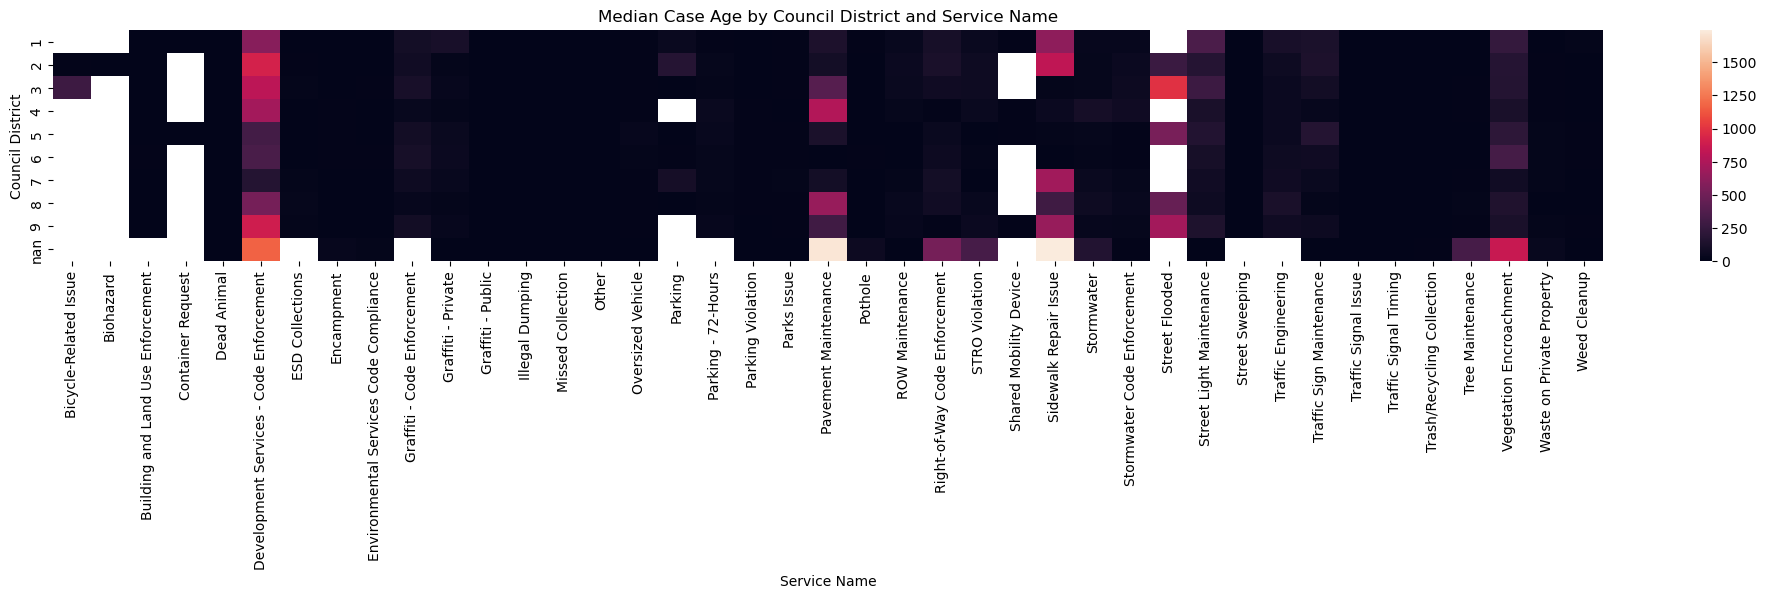

In [28]:
heatmap_data = closed_requests.pivot_table(
    values="case_age_days",
    index="council_district",
    columns="service_name",
    aggfunc="median"
)

plt.figure(figsize=(25, 3))

sns.heatmap(
    heatmap_data,
    #annot=True,
    fmt=".1f"
)

plt.title("Median Case Age by Council District and Service Name")
plt.xlabel("Service Name")
plt.ylabel("Council District")

plt.savefig("heatmap.png")
plt.show()


# ML Prep

select columns needed for ML

In [29]:
ml_df = closed_requests[["service_request_id", "case_age_days", "date_requested", "date_closed", "case_record_type", "service_name", "zipcode", "council_district", "comm_plan_code", "comm_plan_name", "case_origin", "public_description"]]

In [30]:
ml_df

,service_request_id,case_age_days,date_requested,date_closed,case_record_type,service_name,zipcode,council_district,comm_plan_code,comm_plan_name,case_origin,public_description
1,5152705,1,2025-03-19 16:22:00.000,2025-03-20,ESD Complaint/Report,Missed Collection,92109,2,18,MISSION BEACH,Web,Third attempt has not been picked up
2,5152711,27,2025-03-19 16:25:00.000,2025-04-15,Parking,Parking Violation,92117,2,6,CLAIREMONT MESA,Web,Van has been parked for over a month. Windows ...
3,5152712,14,2025-03-19 16:25:00.000,2025-04-02,Neighborhood Policing,Encampment,92101,2,14,MIDWAY-PACIFIC HIGHWAY,Web,A homeless encampment fire was reported at W. ...
4,5152714,3,2025-03-19 16:29:00.000,2025-03-22,Parking,Parking Violation,92110,2,6,CLAIREMONT MESA,Web,Van has been parked on the curb since March 11...
5,5152728,5,2025-03-19 16:37:00.000,2025-03-24,ESD Complaint/Report,Missed Collection,92113,8,37,SOUTHEASTERN SAN DIEGO,Web,Very busy street so I understand if one was mi...
...,...,...,...,...,...,...,...,...,...,...,...,...
378664,4662530,598,2024-03-11 08:48:00.000,2025-10-30,TSW ROW,Right-of-Way Code Enforcement,92128,5,31,Rancho Bernardo,Mobile,Sidewalk eneven
378665,4947796,418,2024-09-28 13:25:00.000,2025-11-20,TSW,Traffic Sign Maintenance,92130,1,21,CARMEL VALLEY,Mobile,On the rightside of eastbound Del Mar Heights ...
378666,5060477,3,2025-01-05 11:22:00.000,2025-01-08,TSW,Pothole,92122,6,99,UNIVERSITY,Web,The entrance to the dog park has a raised edge...
378667,5182329,6,2025-04-12 18:34:00.000,2025-04-18,TSW,Tree Maintenance,92117,2,6,CLAIREMONT MESA,Mobile,Tree blocking sidewalk


In [31]:
meta_df = create_metadata(ml_df)

# Export to CSV file
meta_df.to_csv("metadata_report.csv")

meta_df.head(25)

,dtype,n_unique,missing_sum,is_numeric,is_categorical
service_request_id,int64,350707,0,True,False
case_age_days,int64,2437,0,True,False
date_requested,object,223392,0,False,True
date_closed,object,365,0,False,True
case_record_type,object,11,0,False,True
service_name,object,41,17,False,True
zipcode,object,67,0,False,True
council_district,category,10,0,False,True
comm_plan_code,object,58,0,False,True
comm_plan_name,object,59,1252,False,True


### Dealing with missing values

In [32]:
# drop observations with missing service name
# drop observations with missing zip code

ml_df = ml_df.dropna(
    subset=["service_name", "zipcode", "council_district", "comm_plan_code"]
)

ml_df = ml_df.reset_index(drop=True)

#most_common_origin = ml_df["case_origin"].mode()[0]
#ml_df["case_origin"] = ml_df["case_origin"].fillna(most_common_origin)

In [33]:
meta_df = create_metadata(ml_df)

# Export to CSV file
meta_df.to_csv("metadata_report.csv")

meta_df.head(25)

,dtype,n_unique,missing_sum,is_numeric,is_categorical
service_request_id,int64,350690,0,True,False
case_age_days,int64,2437,0,True,False
date_requested,object,223387,0,False,True
date_closed,object,365,0,False,True
case_record_type,object,11,0,False,True
service_name,object,41,0,False,True
zipcode,object,66,0,False,True
council_district,category,10,0,False,True
comm_plan_code,object,58,0,False,True
comm_plan_name,object,59,1251,False,True


In [34]:
ml_df.shape

(350690, 12)

column for day of week based on date requested, column for season based on date requested, extract text urgent from detail/public description

### Feature Engineering

In [35]:
ml_df["date_requested"] = pd.to_datetime(
    ml_df["date_requested"]
)

ml_df["request_year"] = ml_df["date_requested"].dt.year
ml_df["request_month"] = ml_df["date_requested"].dt.month
ml_df["request_day_of_week"] = ml_df["date_requested"].dt.dayofweek
ml_df["request_quarter"] = ml_df["date_requested"].dt.quarter

In [36]:
ml_df["date_requested"] = pd.to_datetime(ml_df["date_requested"])
ml_df["date_closed"] = pd.to_datetime(ml_df["date_closed"])

# Calculate number of days to close
days_to_close = (
    ml_df["date_closed"] - ml_df["date_requested"]
).dt.days

# Create binary target
ml_df["closed_within_30_days"] = (days_to_close <= 30).astype(int)

In [37]:
urgent_cases = ml_df[
    ml_df["public_description"]
    .fillna("")
    .str.contains("urgent", case=False, na=False)
]

urgent_cases[
    ["service_request_id", "public_description", "case_age_days"]
]

,service_request_id,public_description,case_age_days
1592,5236532,The metal fence at the cormorant nesting site ...,204
2624,5237100,Immediate action is needed regarding severe no...,0
3409,5234436,Here?s a direct and urgent letter you can send...,9
3792,5238874,**URGENT** BROKEN STOP SIGN,2
4671,5238724,I?m following up again regarding the homeless ...,1
...,...,...,...
342408,5485188,This is a second dumpster on the property on O...,6
345572,5416565,URGENT: Silver Prius has been parked here sin...,14
346534,5490955,Two tall palm trees on city sidewalk landscape...,1
349085,5495637,Tree on 8056 san felipe st. Forgot to mention ...,1


In [38]:
urgency_terms = [
    "urgent",
    "urgently",
    "emergency",
    "immediately",
    "immediate",
    "asap",
    "danger",
    "dangerous",
    "hazard",
    "hazardous",
    "unsafe",
    "critical"
]

pattern = "|".join(urgency_terms)

urgent_cases = ml_df[
    ml_df["public_description"]
    .fillna("")
    .str.contains(pattern, case=False, na=False)
]

In [39]:
urgent_cases[
    ["service_request_id", "public_description", "case_age_days"]
].head(5)

,service_request_id,public_description,case_age_days
1,5152711,Van has been parked for over a month. Windows ...,27
18,5152934,Around Kettner and Grape - this area needs imm...,48
53,5153300,"LARGE POTHOLE. DANGEROUS AND HAZARDOUS, PER OF...",0
111,5153877,The new bike lane for Clairemont Dr. is causin...,1
122,5153971,Recently the sidewalk in front of the Windsor ...,26


In [40]:
for term in urgency_terms:
    count = (
        ml_df["public_description"]
        .fillna("")
        .str.contains(term, case=False, na=False)
        .sum()
    )

    print(f"{term}: {count}")

urgent: 276
urgently: 78
emergency: 761
immediately: 760
immediate: 1516
asap: 1195
danger: 4576
dangerous: 3785
hazard: 5899
hazardous: 661
unsafe: 1528
critical: 68


In [41]:
ml_df["urgent_language"] = (
    ml_df["public_description"]
    .fillna("")
    .str.contains(pattern, case=False, na=False)
    .astype(int)
)

In [42]:
ml_df.groupby("urgent_language")["case_age_days"].describe()

,count,mean,std,min,25%,50%,75%,max
urgent_language,,,,,,,,
0,336185.0,45.143079,186.508716,0.0,0.0,3.0,15.0,3478.0
1,14505.0,141.354498,403.714793,0.0,1.0,8.0,51.0,3367.0


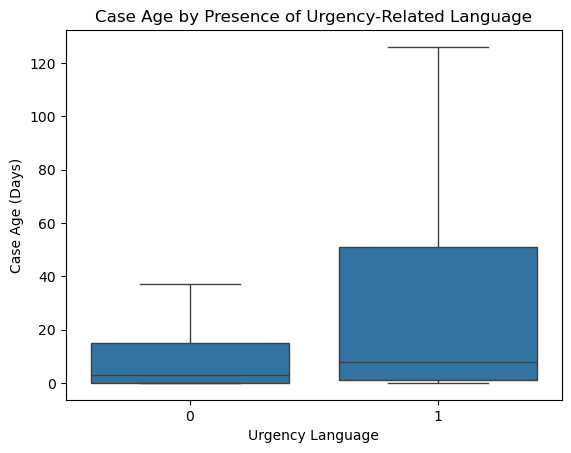

In [43]:
sns.boxplot(
    data=ml_df,
    x="urgent_language",
    y="case_age_days",
    showfliers=False
)

plt.xlabel("Urgency Language")
plt.ylabel("Case Age (Days)")
plt.title("Case Age by Presence of Urgency-Related Language")
plt.show()

In [44]:
ml_df = ml_df.drop(columns = ["public_description", "date_requested", "date_closed"])

In [45]:
ml_df

,service_request_id,case_age_days,case_record_type,service_name,zipcode,council_district,comm_plan_code,comm_plan_name,case_origin,request_year,request_month,request_day_of_week,request_quarter,closed_within_30_days,urgent_language
0,5152705,1,ESD Complaint/Report,Missed Collection,92109,2,18,MISSION BEACH,Web,2025,3,2,1,1,0
1,5152711,27,Parking,Parking Violation,92117,2,6,CLAIREMONT MESA,Web,2025,3,2,1,1,1
2,5152712,14,Neighborhood Policing,Encampment,92101,2,14,MIDWAY-PACIFIC HIGHWAY,Web,2025,3,2,1,1,0
3,5152714,3,Parking,Parking Violation,92110,2,6,CLAIREMONT MESA,Web,2025,3,2,1,1,0
4,5152728,5,ESD Complaint/Report,Missed Collection,92113,8,37,SOUTHEASTERN SAN DIEGO,Web,2025,3,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350685,4662530,598,TSW ROW,Right-of-Way Code Enforcement,92128,5,31,Rancho Bernardo,Mobile,2024,3,0,1,0,0
350686,4947796,418,TSW,Traffic Sign Maintenance,92130,1,21,CARMEL VALLEY,Mobile,2024,9,5,3,0,0
350687,5060477,3,TSW,Pothole,92122,6,99,UNIVERSITY,Web,2025,1,6,1,1,0
350688,5182329,6,TSW,Tree Maintenance,92117,2,6,CLAIREMONT MESA,Mobile,2025,4,5,2,1,0


Separate out dataframes based on variables needed for each ML problem

In [46]:
linear_df = ml_df.drop(columns = ["closed_within_30_days"])
logistic_df = ml_df.drop(columns = ["case_age_days"])
col = logistic_df.pop("closed_within_30_days")
logistic_df.insert(0, "closed_within_30_days", col)
kmeans_df = ml_df.drop(columns = ["closed_within_30_days", "case_age_days"])

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

### Logistic Regression

Step 1: Check the actual target and predictor columns


In [48]:
print("Logistic regression dataset shape:", logistic_df.shape)

print("\nColumns:")
print(logistic_df.columns.tolist())

print("\nTarget distribution:")
print(logistic_df["closed_within_30_days"].value_counts())

print("\nTarget proportions:")
print(logistic_df["closed_within_30_days"].value_counts(normalize=True))

print("\nMissing values:")
print(logistic_df.isnull().sum())

Logistic regression dataset shape: (350690, 14)

Columns:
['closed_within_30_days', 'service_request_id', 'case_record_type', 'service_name', 'zipcode', 'council_district', 'comm_plan_code', 'comm_plan_name', 'case_origin', 'request_year', 'request_month', 'request_day_of_week', 'request_quarter', 'urgent_language']

Target distribution:
closed_within_30_days
1    290283
0     60407
Name: count, dtype: int64

Target proportions:
closed_within_30_days
1    0.827748
0    0.172252
Name: proportion, dtype: float64

Missing values:
closed_within_30_days       0
service_request_id          0
case_record_type            0
service_name                0
zipcode                     0
council_district            0
comm_plan_code              0
comm_plan_name           1251
case_origin                71
request_year                0
request_month               0
request_day_of_week         0
request_quarter             0
urgent_language             0
dtype: int64


Step 2: Create X and y + train/test split


In [49]:
from sklearn.model_selection import train_test_split

# Target
y = logistic_df["closed_within_30_days"]

# Predictors
X = logistic_df.drop(columns=["closed_within_30_days", "service_request_id"])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest target proportions:")
print(y_test.value_counts(normalize=True))

X_train: (280552, 12)
X_test: (70138, 12)
y_train: (280552,)
y_test: (70138,)

Training target proportions:
closed_within_30_days
1    0.827747
0    0.172253
Name: proportion, dtype: float64

Test target proportions:
closed_within_30_days
1    0.827754
0    0.172246
Name: proportion, dtype: float64


Step 3: Define preprocessing

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

categorical_features = [
    "case_record_type",
    "service_name",
    "zipcode",
    "council_district",
    "comm_plan_code",
    "comm_plan_name",
    "case_origin"
]

numeric_features = [
    "request_year",
    "request_month",
    "request_day_of_week",
    "request_quarter",
    "urgent_language"
]

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features)
])

Step 4: Build and fit the baseline

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['case_record_type',
                                                   'service_name', 'zipcode',
                                                   'council_district',
                                                   'comm_plan_code',
                                                   'comm_plan_name',
                                                   'case_origin']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['request_year',
                                                   'request_month',
                                                   'request_day_of_week',
                                                   'request_quarter',
                                                   'urgent_language'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

Step 5: baseline eval

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Make predictions
y_pred_baseline = baseline_model.predict(X_test)

# Calculate metrics
baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(y_test, y_pred_baseline),
    "Recall": recall_score(y_test, y_pred_baseline),
    "F1": f1_score(y_test, y_pred_baseline),
    "Macro F1": f1_score(y_test, y_pred_baseline, average="macro")
}

print("Baseline Logistic Regression")
print("-" * 35)

for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Baseline Logistic Regression
-----------------------------------
Accuracy: 0.8912
Precision: 0.8998
Recall: 0.9773
F1: 0.9370
Macro F1: 0.7694

Confusion Matrix:
[[ 5766  6315]
 [ 1317 56740]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.48      0.60     12081
           1       0.90      0.98      0.94     58057

    accuracy                           0.89     70138
   macro avg       0.86      0.73      0.77     70138
weighted avg       0.89      0.89      0.88     70138



Step 6: Hyperparameter tuning

In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"],
    "classifier__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['case_record_type',
                                                                          'service_name',
                                                                          'zipcode',
                                                                          'council_district',
                                                                          'comm_plan_code',
                                                                          'comm_plan_name',
                                                                          'case_origin']),
                                                                        ('numeric...
                                                                                          StandardScaler())]),
                                                                         ['request_year',
                                                                          'request_month',
                                                                          'request_day_of_week',
                                                                          'request_quarter',
                                                                          'urgent_language'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__class_weight': [None, 'balanced'],
                         'classifier__solver': ['liblinear', 'lbfgs']},
             scoring='f1_macro', verbose=1)

In [54]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation macro F1:")

print(f"{grid_search.best_score_:.4f}")

Best parameters:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__solver': 'liblinear'}

Best cross-validation macro F1:
0.7735


Step 7: Eval of tuned model



In [55]:
tuned_model = grid_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test)

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1": f1_score(y_test, y_pred_tuned),
    "Macro F1": f1_score(y_test, y_pred_tuned, average="macro")
}

print("Tuned Logistic Regression")
print("-" * 35)

for metric, value in tuned_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))


Tuned Logistic Regression
-----------------------------------
Accuracy: 0.8912
Precision: 0.8999
Recall: 0.9773
F1: 0.9370
Macro F1: 0.7695

Confusion Matrix:
[[ 5769  6312]
 [ 1318 56739]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.48      0.60     12081
           1       0.90      0.98      0.94     58057

    accuracy                           0.89     70138
   macro avg       0.86      0.73      0.77     70138
weighted avg       0.89      0.89      0.88     70138



Step 8: check what class weighing did

In [56]:
cv_results = pd.DataFrame(grid_search.cv_results_)

class_weight_results = (
    cv_results
    .groupby("param_classifier__class_weight")["mean_test_score"]
    .max()
    .sort_values(ascending=False)
)

print("Best CV Macro F1 by class weight:")
print(class_weight_results)

Best CV Macro F1 by class weight:
param_classifier__class_weight
balanced    0.729297
Name: mean_test_score, dtype: float64


step 9: Class 0 weighing

In [57]:
class0_weighted_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=10,
        solver="liblinear",
        class_weight={0: 2, 1: 1},
        max_iter=1000,
        random_state=42
    ))
])

class0_weighted_model.fit(X_train, y_train)

y_pred_class0 = class0_weighted_model.predict(X_test)

class0_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_class0),
    "Precision": precision_score(y_test, y_pred_class0),
    "Recall": recall_score(y_test, y_pred_class0),
    "F1": f1_score(y_test, y_pred_class0),
    "Macro F1": f1_score(y_test, y_pred_class0, average="macro")
}

print("Class 0 Weighted Logistic Regression")
print("-" * 40)

for metric, value in class0_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class0))

Class 0 Weighted Logistic Regression
----------------------------------------
Accuracy: 0.8782
Precision: 0.9160
Recall: 0.9390
F1: 0.9274
Macro F1: 0.7756

Confusion Matrix:
[[ 7081  5000]
 [ 3540 54517]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.59      0.62     12081
           1       0.92      0.94      0.93     58057

    accuracy                           0.88     70138
   macro avg       0.79      0.76      0.78     70138
weighted avg       0.87      0.88      0.88     70138



Step 10: comparing class 0 weights

In [58]:
class0_weights = [1, 1.5, 2, 2.5, 3]

weight_results = []

for weight in class0_weights:

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            C=10,
            solver="liblinear",
            class_weight={0: weight, 1: 1},
            max_iter=1000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    weight_results.append({
        "Class 0 Weight": weight,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro")
    })

weight_results_df = pd.DataFrame(weight_results)

print(weight_results_df.round(4))

   Class 0 Weight  Accuracy  Precision  Recall      F1  Macro F1
0             1.0    0.8912     0.8999  0.9773  0.9370    0.7695
1             1.5    0.8880     0.9090  0.9609  0.9342    0.7787
2             2.0    0.8782     0.9160  0.9390  0.9274    0.7756
3             2.5    0.8622     0.9214  0.9112  0.9163    0.7633
4             3.0    0.8484     0.9300  0.8834  0.9061    0.7567


Step 11: Setting up SMOTENC pre processing

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

smote_preprocessor = ColumnTransformer([
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]),
        categorical_features
    ),
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_features
    )
])

smotenc_model = ImbPipeline([
    ("preprocessor", smote_preprocessor),
    ("smotenc", SMOTENC(
        categorical_features=list(range(len(categorical_features))),
        random_state=42
    )),
    ("classifier", LogisticRegression(
        C=10,
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])

Step 12: complete smotenc pipeline

In [60]:
post_smote_preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        list(range(len(categorical_features)))
    ),
    (
        "numeric",
        "passthrough",
        list(range(
            len(categorical_features),
            len(categorical_features) + len(numeric_features)
        ))
    )
])

smotenc_model = ImbPipeline([
    ("preprocessor", smote_preprocessor),
    ("smotenc", SMOTENC(
        categorical_features=list(range(len(categorical_features))),
        random_state=42
    )),
    ("post_smote", post_smote_preprocessor),
    ("classifier", LogisticRegression(
        C=10,
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])

In [62]:
# fit the SMOTENC model on the training data

smotenc_model.fit(X_train, y_train)

print("SMOTENC logistic regression fitted successfully.")

SMOTENC logistic regression fitted successfully.


step 13: eval smotenc

In [63]:
y_pred_smotenc = smotenc_model.predict(X_test)

smotenc_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_smotenc),
    "Precision": precision_score(y_test, y_pred_smotenc),
    "Recall": recall_score(y_test, y_pred_smotenc),
    "F1": f1_score(y_test, y_pred_smotenc),
    "Macro F1": f1_score(y_test, y_pred_smotenc, average="macro")
}

print("SMOTENC Logistic Regression")
print("-" * 35)

for metric, value in smotenc_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smotenc))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smotenc))

SMOTENC Logistic Regression
-----------------------------------
Accuracy: 0.8000
Precision: 0.9570
Recall: 0.7941
F1: 0.8680
Macro F1: 0.7280

Confusion Matrix:
[[10007  2074]
 [11953 46104]]

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.83      0.59     12081
           1       0.96      0.79      0.87     58057

    accuracy                           0.80     70138
   macro avg       0.71      0.81      0.73     70138
weighted avg       0.87      0.80      0.82     70138



step 14: threshhold analysis

In [64]:
y_prob_class0 = class0_weighted_model.predict_proba(X_test)[:, 1]

In [ ]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_class0 >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1": f1_score(y_test, y_pred_threshold),
        "Macro F1": f1_score(
            y_test,
            y_pred_threshold,
            average="macro"
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

print(threshold_results_df.round(4))

   Threshold  Accuracy  Precision  Recall      F1  Macro F1
0       0.30    0.8894     0.8959  0.9804  0.9362    0.7606
1       0.35    0.8913     0.9017  0.9750  0.9369    0.7724
2       0.40    0.8903     0.9067  0.9669  0.9358    0.7784
3       0.45    0.8861     0.9107  0.9561  0.9329    0.7786
4       0.50    0.8783     0.9160  0.9391  0.9274    0.7757
5       0.55    0.8651     0.9209  0.9157  0.9183    0.7659
6       0.60    0.8490     0.9290  0.8852  0.9066    0.7564
7       0.65    0.8311     0.9400  0.8502  0.8929    0.7470
8       0.70    0.8057     0.9542  0.8038  0.8726    0.7317


step 15: final model comparison

In [65]:
final_comparison = pd.DataFrame([
    {
        "Model": "Baseline",
        **baseline_metrics
    },
    {
        "Model": "Tuned",
        **tuned_metrics
    },
    {
        "Model": "Class 0 Weight 1.5",
        **weight_results_df.loc[
            weight_results_df["Class 0 Weight"] == 1.5
        ].iloc[0].drop("Class 0 Weight").to_dict()
    },
    {
        "Model": "SMOTENC",
        **smotenc_metrics
    }
])

print(final_comparison.round(4))

                Model  Accuracy  Precision  Recall      F1  Macro F1
0            Baseline    0.8912     0.8998  0.9773  0.9370    0.7694
1               Tuned    0.8912     0.8999  0.9773  0.9370    0.7695
2  Class 0 Weight 1.5    0.8880     0.9090  0.9609  0.9342    0.7787
3             SMOTENC    0.8000     0.9570  0.7941  0.8680    0.7280


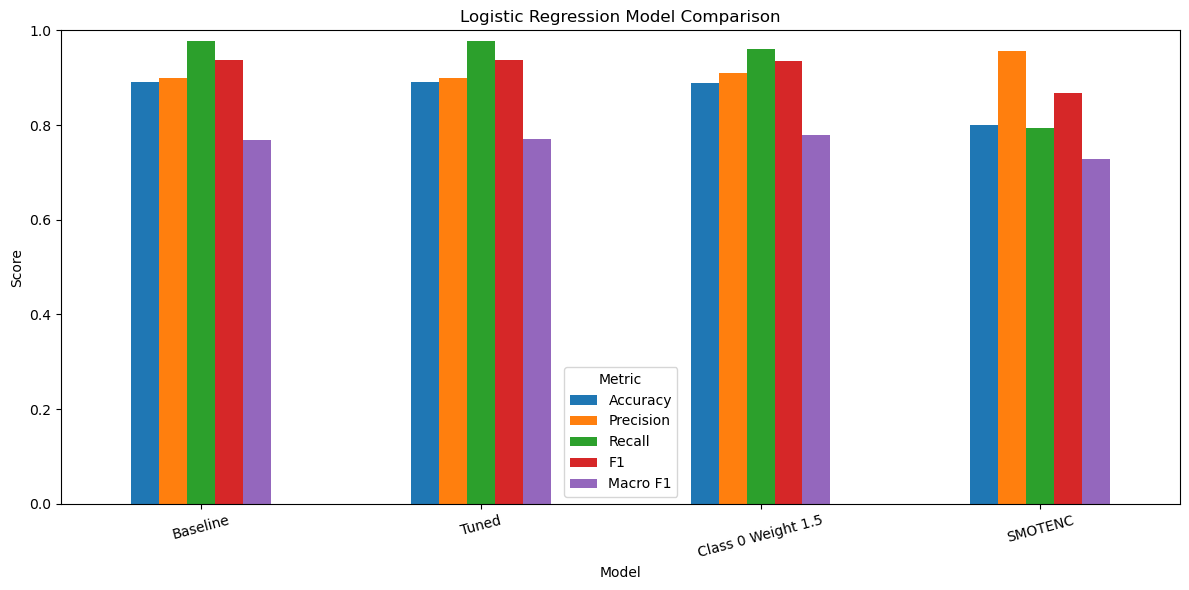

In [66]:
# visual of comparison of models

final_comparison.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1", "Macro F1"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Logistic Regression Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

step 16: class 0 v class 1 performance

In [67]:
class_report_models = {
    "Baseline": classification_report(
        y_test, y_pred_baseline, output_dict=True
    ),
    "Tuned": classification_report(
        y_test, y_pred_tuned, output_dict=True
    ),
    "Class 0 Weight 1.5": classification_report(
        y_test,
        (y_prob_class0 >= 0.50).astype(int),
        output_dict=True
    ),
    "SMOTENC": classification_report(
        y_test, y_pred_smotenc, output_dict=True
    )
}

class_performance = pd.DataFrame({
    model: {
        "Class 0 F1": report["0"]["f1-score"],
        "Class 1 F1": report["1"]["f1-score"]
    }
    for model, report in class_report_models.items()
}).T

print(class_performance.round(4))

                    Class 0 F1  Class 1 F1
Baseline                0.6018      0.9370
Tuned                   0.6019      0.9370
Class 0 Weight 1.5      0.6238      0.9274
SMOTENC                 0.5879      0.8680


## Step 17: Model Comparison

The four logistic regression approaches were compared using accuracy, precision, recall, F1, and macro F1. Macro F1 was given particular attention because the target variable is imbalanced, with class 1 representing approximately 83% of the observations.

| Model | Accuracy | Precision | Recall | F1 | Macro F1 |
|---|---:|---:|---:|---:|---:|
| Baseline | 0.8911 | 0.8998 | 0.9773 | 0.9369 | 0.7691 |
| Tuned | 0.8913 | 0.8999 | 0.9774 | 0.9371 | 0.7696 |
| Class 0 Weight 1.5 | 0.8883 | 0.9091 | 0.9612 | 0.9344 | 0.7792 |
| SMOTENC | 0.8003 | 0.9569 | 0.7946 | 0.8682 | 0.7282 |

The class-specific F1 scores were also compared to examine how each approach handled the two classes.

| Model | Class 0 F1 | Class 1 F1 |
|---|---:|---:|
| Baseline | 0.6013 | 0.9369 |
| Tuned | 0.6021 | 0.9371 |
| Class 0 Weight 1.5 | 0.6240 | 0.9274 |
| SMOTENC | 0.5882 | 0.8682 |

The Class 0 Weight 1.5 model produced the highest macro F1 among the four approaches tested. It also improved the F1 score for class 0 compared with the baseline and tuned models, while maintaining relatively strong performance for class 1.

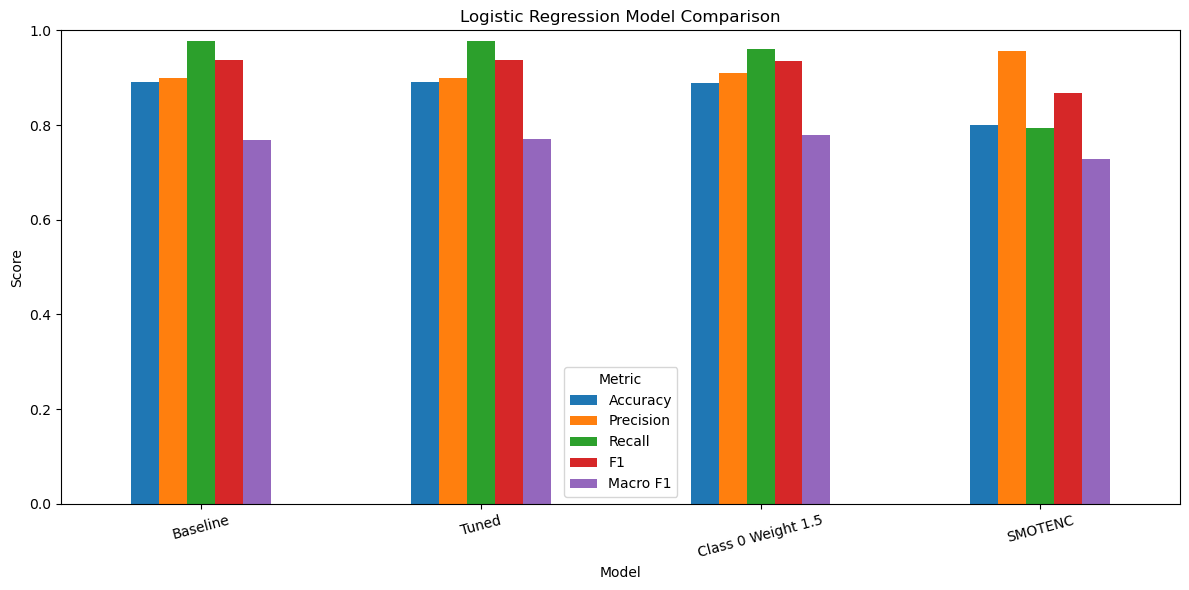

In [68]:
final_comparison.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1", "Macro F1"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Logistic Regression Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

Step 18: create 1.5 weight model

In [69]:
class0_weight_15_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=10,
        solver="liblinear",
        class_weight={0: 1.5, 1: 1},
        max_iter=1000,
        random_state=42
    ))
])

class0_weight_15_model.fit(X_train, y_train)

y_pred_weight_15 = class0_weight_15_model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_weight_15))

              precision    recall  f1-score   support

           0       0.74      0.54      0.62     12081
           1       0.91      0.96      0.93     58058

    accuracy                           0.89     70139
   macro avg       0.83      0.75      0.78     70139
weighted avg       0.88      0.89      0.88     70139



## Step 19: Model Performance Comparison

The models were compared using several measures of prediction performance:

- **Overall correctness (Accuracy):** the percentage of all predictions that were correct.
- **Correct positive predictions (Precision):** how often predictions of cases resolved within 30 days were correct.
- **Correctly identified positive cases (Recall):** how many cases actually resolved within 30 days were correctly identified.
- **Balance between precision and recall (F1 score):** combines precision and recall into one measure.
- **Balanced performance across both classes (Macro F1):** calculates the F1 score for each class separately and gives both classes equal importance.

Because most cases in the dataset were resolved within 30 days, macro F1 is particularly useful for comparing how well the models handled both classes rather than focusing primarily on the majority class.

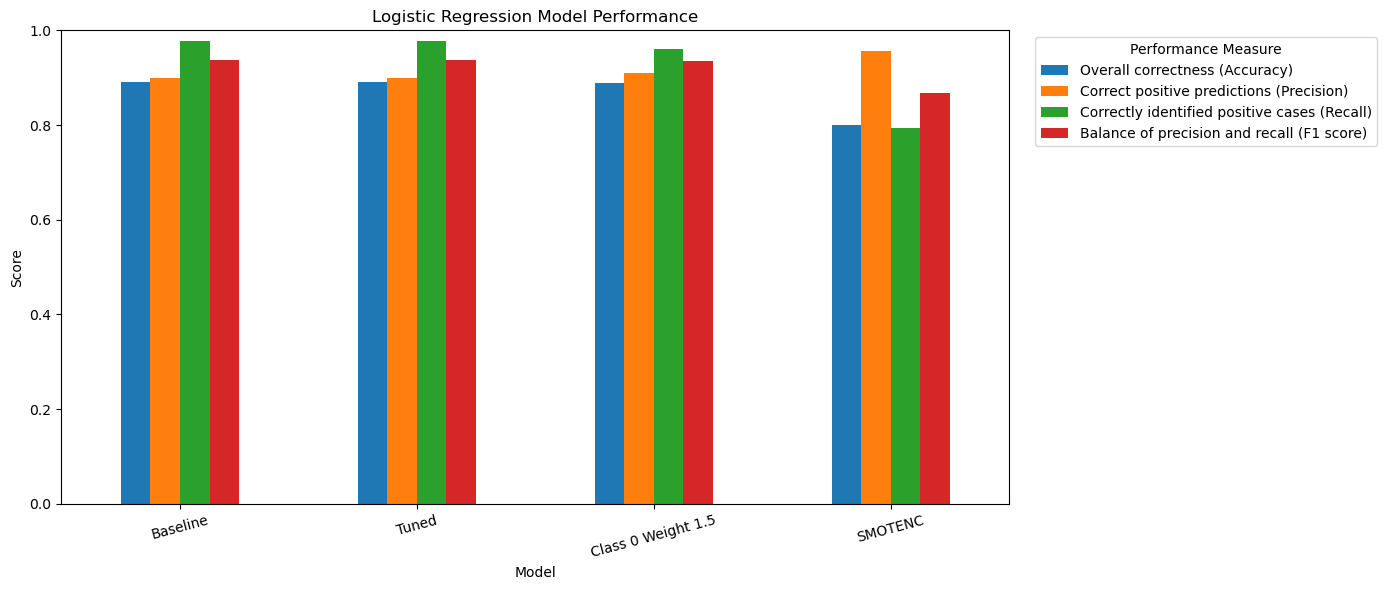

In [70]:
final_comparison.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1"],
    kind="bar",
    figsize=(14, 6)
)

plt.title("Logistic Regression Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.legend(
    title="Performance Measure",
    labels=[
        "Overall correctness (Accuracy)",
        "Correct positive predictions (Precision)",
        "Correctly identified positive cases (Recall)",
        "Balance of precision and recall (F1 score)"
    ],
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig("logistic_regression_model_performance.png", dpi=300, bbox_inches="tight")

plt.show()

## Step 20: Performance by Resolution Group

The F1 score was also examined separately for each outcome class. Class 0 represents cases that were **not resolved within 30 days**, while class 1 represents cases that **were resolved within 30 days**.

**F1 score (balance between precision and recall)** is used here to show how well each model handled each resolution group.

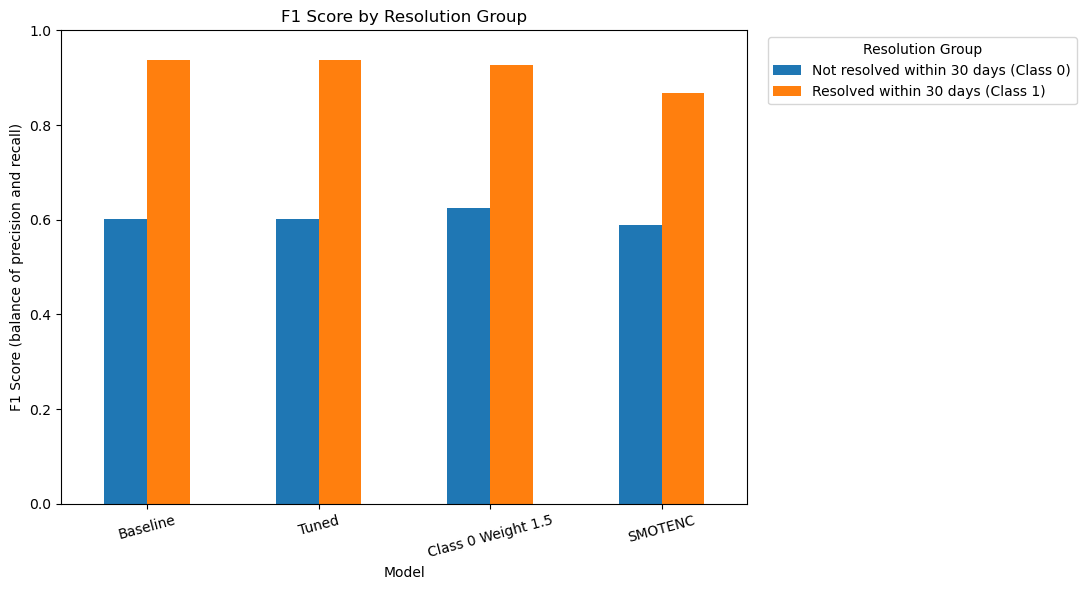

In [71]:
class_performance.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("F1 Score by Resolution Group")
plt.ylabel("F1 Score (balance of precision and recall)")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(
    title="Resolution Group",
    labels=[
        "Not resolved within 30 days (Class 0)",
        "Resolved within 30 days (Class 1)"
    ],
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.savefig(
    "f1_score_by_resolution_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 21: Confusion Matrix

A confusion matrix shows the number of cases the model classified correctly and incorrectly.

- **True negative:** correctly predicted a case would not be resolved within 30 days.
- **False positive:** predicted a case would be resolved within 30 days when it was not.
- **False negative:** predicted a case would not be resolved within 30 days when it was actually resolved within 30 days.
- **True positive:** correctly predicted a case would be resolved within 30 days.

For this model, the overall correctness (Accuracy) was **88.83%**, while the balance between both classes (Macro F1) was **77.92%**. The F1 score for cases not resolved within 30 days (Class 0) was **62.40%**, compared with **92.74%** for cases resolved within 30 days (Class 1).

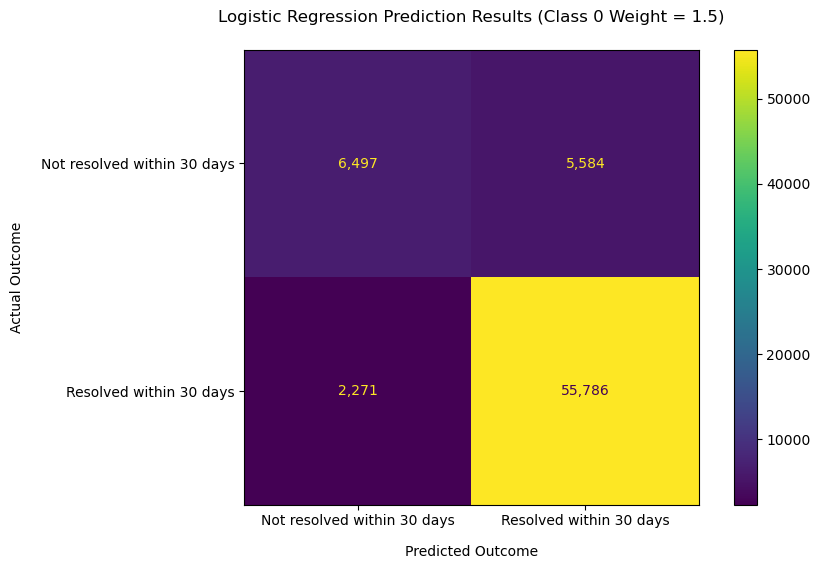

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_weight_15)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not resolved within 30 days",
        "Resolved within 30 days"
    ]
)

disp.plot(values_format=",", ax=ax)

ax.set_title(
    "Logistic Regression Prediction Results (Class 0 Weight = 1.5)",
    pad=20
)

ax.set_xlabel("Predicted Outcome", labelpad=12)
ax.set_ylabel("Actual Outcome", labelpad=12)

plt.subplots_adjust(
    top=0.85,
    bottom=0.20
)

plt.savefig(
    "logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

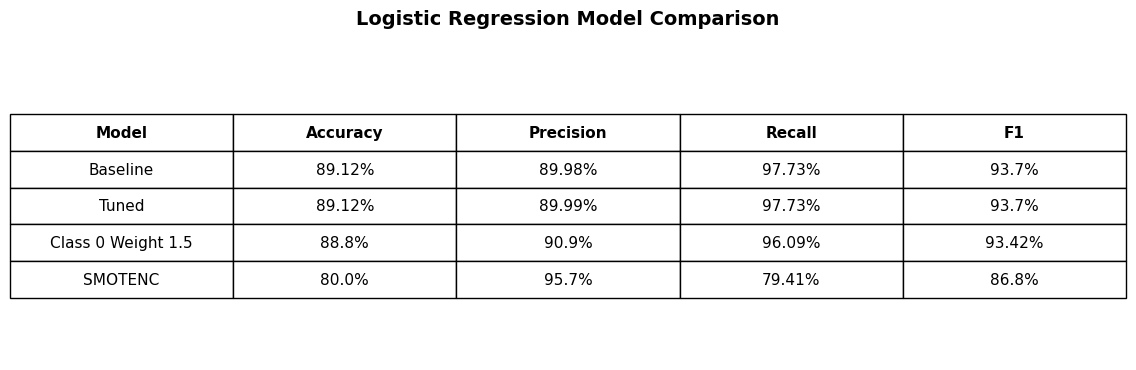

Exception ignored in: <function ResourceTracker.__del__ at 0x103be5c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102d8dc60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1032f5c60>
Traceback (most recent call last

In [73]:
# Keep only the metrics needed for the paper
comparison_table = final_comparison[
    ["Model", "Accuracy", "Precision", "Recall", "F1"]
].copy()

# Convert values to percentages
for col in ["Accuracy", "Precision", "Recall", "F1"]:
    comparison_table[col] = (
        (comparison_table[col] * 100)
        .round(2)
        .astype(str) + "%"
    )

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

table = ax.table(
    cellText=comparison_table.values,
    colLabels=comparison_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

# Formatting
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.2)

# Bold column headers
for col in range(len(comparison_table.columns)):
    table[(0, col)].set_text_props(weight="bold")

# Title
ax.set_title(
    "Logistic Regression Model Comparison",
    fontsize=14,
    fontweight="bold",
    pad=20
)

# Save as PNG
plt.savefig(
    "logistic_regression_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2
)

plt.show()